<a href="https://colab.research.google.com/github/WVF-1/Pittsburgh-Traffic-Flow/blob/main/traffic_road_network_and_commute_flows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Part 1: The Road Network & Where People Actually Go

**Newsletter series: Geospatial Data & Public Transportation — Project 2 of 5 (EDA)**

Project 1 got us comfortable with geospatial basics using bike infrastructure. This project shifts to **traffic flow**, and starts building the pieces that Projects 3-5 (modeling, architecture/simulation, and the GNN) will depend on:

- The street network, now classified by **road hierarchy** (highway vs. arterial vs. local street) — this becomes edge "capacity" information later
- **Commuting flow data** — actual origin → destination movement between home and work locations, which is the closest thing to real traffic flow we can get without a paid data feed

This notebook also introduces a new technique you asked about: **overlaying data on a real map** (actual streets, labels, terrain) instead of a blank white background.

**Data sources — both fully open, both pulled via Python:**
- Road network: [OpenStreetMap](https://www.openstreetmap.org/) via `osmnx` (ODbL license — same as Project 1)
- Commuting flows: [Census LEHD LODES](https://lehd.ces.census.gov/data/) (LEHD Origin-Destination Employment Statistics) — U.S. Census Bureau, public domain, no API key, no account, direct file download
- Basemap tiles: via `contextily`, sourced from CartoDB's free tile service

**A quick note on an option we're skipping:** PennDOT does publish traffic volume (AADT) data, but its open data portal's license text is ambiguous — "provided for informational and planning purposes only" isn't a clear open license, similar to the WPRDC situation from Project 1. We're sticking with OSM + Census, both unambiguously open.

## Setup

In [1]:
!pip install osmnx geopandas contextily pygris -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.9 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
import requests
import io
import gzip

ox.settings.log_console = False

# Palette: keep gold/black from Project 1 for continuity, add a traffic-specific
# accent (warm orange/red reads as "flow/activity" -- distinct from bike green).
PGH_GOLD  = "#FFB81C"
PGH_BLACK = "#1a1a1a"
FLOW_CMAP = "OrRd"

HIGHWAY_COLORS = {
    "Highway":    "#8c1c13",   # motorway/trunk
    "Primary":    "#c1440e",
    "Secondary":  "#e8871e",
    "Tertiary":   "#f2b134",
    "Local":      "#c9c9c9",
}


## Part 1: The road network, classified by hierarchy

Last time we pulled a *bike*-routable network. This time we want the **drivable** network, and instead of flagging bike lanes, we'll classify every street by its `highway` tag into a simplified functional hierarchy. This is standard transportation-planning vocabulary:

| OSM tag | Simplified class | What it means |
|---|---|---|
| `motorway`, `trunk` | Highway | Interstates, limited-access roads |
| `primary` | Primary | Major arterials |
| `secondary` | Secondary | Collector roads |
| `tertiary` | Tertiary | Minor collectors |
| everything else | Local | Residential/local streets |

This classification is what will eventually give the GNN a notion of road "capacity" — a highway and a residential street shouldn't behave the same way in a simulation.

In [3]:
place = "Pittsburgh, Pennsylvania, USA"

G = ox.graph_from_place(place, network_type="drive")
print(f"Nodes: {len(G.nodes):,}   Edges: {len(G.edges):,}")

G_proj = ox.project_graph(G)
nodes, edges = ox.graph_to_gdfs(G_proj)


Nodes: 9,106   Edges: 23,661


In [4]:
HIERARCHY_MAP = {
    "motorway": "Highway", "motorway_link": "Highway",
    "trunk": "Highway", "trunk_link": "Highway",
    "primary": "Primary", "primary_link": "Primary",
    "secondary": "Secondary", "secondary_link": "Secondary",
    "tertiary": "Tertiary", "tertiary_link": "Tertiary",
}

def classify(row):
    hw = row.get("highway")
    if isinstance(hw, list):
        hw = hw[0]
    return HIERARCHY_MAP.get(hw, "Local")

edges["road_class"] = edges.apply(classify, axis=1)
edges["road_class"].value_counts()


,count
road_class,
Local,16738
Tertiary,3061
Secondary,1830
Primary,1404
Highway,628


## Your first "real map" visual

This is the technique in action. `contextily.add_basemap()` drops actual map tiles behind whatever GeoPandas plotted — streets, labels, terrain all show through underneath your data. The only requirement: your GeoDataFrame needs to be in Web Mercator (`EPSG:3857`), which is the projection basemap tiles are served in.

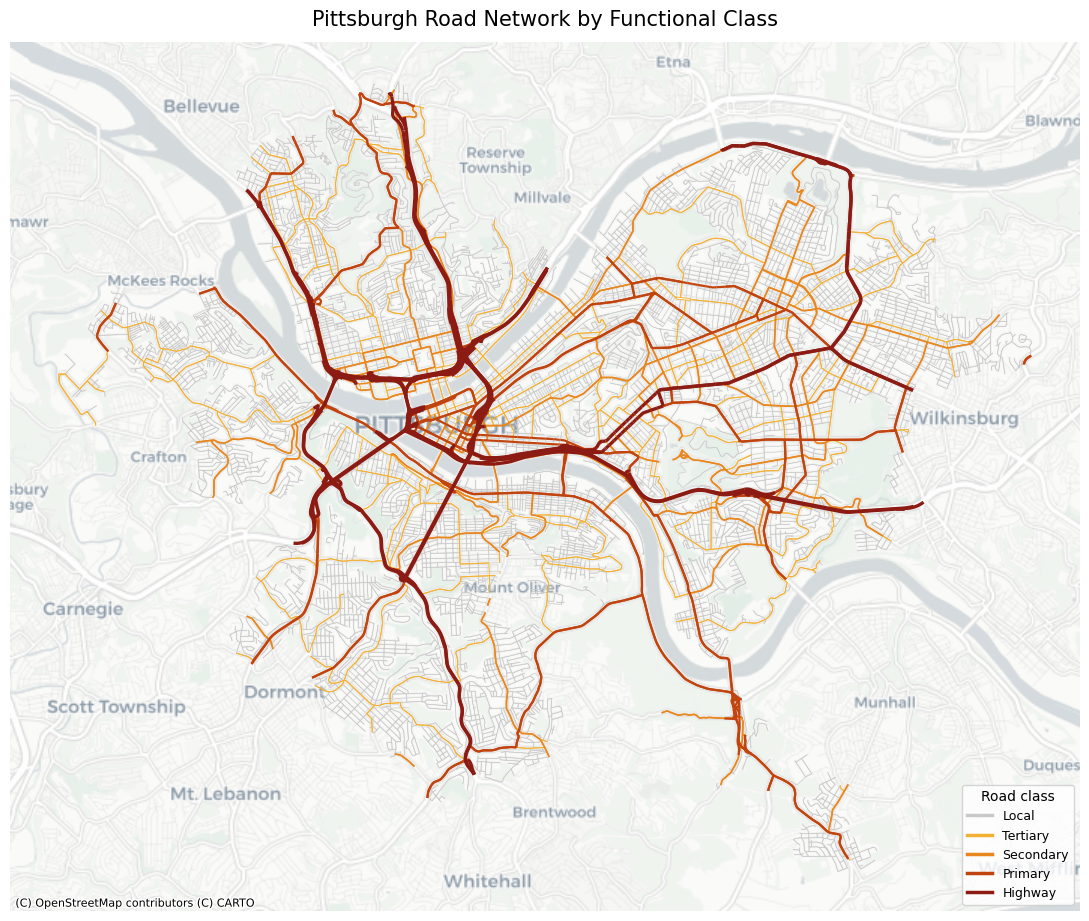

In [5]:
edges_3857 = edges.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# Draw local streets first (thin, gray, background), then progressively
# more important roads on top, thicker and more saturated.
draw_order = ["Local", "Tertiary", "Secondary", "Primary", "Highway"]
widths = {"Local": 0.4, "Tertiary": 0.7, "Secondary": 1.1, "Primary": 1.6, "Highway": 2.4}

for cls in draw_order:
    subset = edges_3857[edges_3857["road_class"] == cls]
    subset.plot(ax=ax, color=HIGHWAY_COLORS[cls], linewidth=widths[cls], zorder=draw_order.index(cls) + 1)

# The one extra line that makes it a real map:
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=0)

# Manual legend since we plotted in a loop
handles = [plt.Line2D([0], [0], color=HIGHWAY_COLORS[c], linewidth=2.5, label=c) for c in draw_order]
ax.legend(handles=handles, loc="lower right", title="Road class", fontsize=9)

ax.set_title("Pittsburgh Road Network by Functional Class", fontsize=15, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("pittsburgh_road_hierarchy_map.png", dpi=200, bbox_inches="tight")
plt.show()


Notice the difference from Project 1's maps: you can actually see the rivers, recognize the Downtown grid, see where the highways cut through. That context is doing a lot of work for the reader — they don't need a legend to know "oh, that's the Parkway" or "that's the Mon."

A quick length breakdown by class, since the visual alone doesn't tell you proportions:

In [6]:
length_by_class = edges.groupby("road_class")["length"].sum().div(1609.34).round(1)
length_by_class = length_by_class.reindex(draw_order)
print("Miles of road by functional class:")
print(length_by_class)


Miles of road by functional class:
road_class
Local        1293.9
Tertiary      226.1
Secondary     142.4
Primary       124.0
Highway       109.7
Name: length, dtype: float64


## Part 2: Where people actually go — commuting flow data

Road hierarchy tells us street *capacity*. It doesn't tell us where traffic actually concentrates. For that, we bring in Census LODES — home-to-work commuting flows, at the census block level, built from real employment records (not a survey sample).

We're pulling the **OD (Origin-Destination) file** for Pennsylvania, "main" version (jobs where both home and work are in-state), all jobs (`JT00`).

In [7]:
LODES_YEAR = 2022  # check https://lehd.ces.census.gov/data/#lodes for the latest available year
LODES_URL = f"https://lehd.ces.census.gov/data/lodes/LODES8/pa/od/pa_od_main_JT00_{LODES_YEAR}.csv.gz"

resp = requests.get(LODES_URL)
resp.raise_for_status()

od = pd.read_csv(io.BytesIO(resp.content), compression="gzip", dtype={"w_geocode": str, "h_geocode": str})
print(f"Total OD pairs (statewide): {len(od):,}")
od.head()


Total OD pairs (statewide): 5,079,012


,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,createdate
0,420010301011003,420010301012063,1,1,0,0,1,0,0,1,0,0,20240920
1,420010301011003,420010303001018,1,0,0,1,0,1,0,1,0,0,20240920
2,420010301011011,420010301011020,1,0,1,0,0,0,1,1,0,0,20240920
3,420010301011011,420010301011045,1,0,0,1,0,1,0,1,0,0,20240920
4,420010301011011,420010301011052,1,0,0,1,0,1,0,1,0,0,20240920


`w_geocode` = workplace census block, `h_geocode` = home census block, both 15-digit FIPS codes. `S000` is total jobs for that home→work pair. The first 5 digits of a block code are the state+county FIPS — Allegheny County is `42003`.

In [8]:
ALLEGHENY_FIPS = "42003"

# Keep pairs where the *workplace* is in Allegheny County -- this captures
# both people commuting within the county and people commuting in from elsewhere.
od_allegheny = od[od["w_geocode"].str[:5] == ALLEGHENY_FIPS].copy()

# Tract GEOID = first 11 digits of the 15-digit block code
od_allegheny["w_tract"] = od_allegheny["w_geocode"].str[:11]
od_allegheny["h_tract"] = od_allegheny["h_geocode"].str[:11]

print(f"OD pairs with workplace in Allegheny County: {len(od_allegheny):,}")


OD pairs with workplace in Allegheny County: 631,035


In [9]:
# Aggregate to tract level: total jobs (inflow) per workplace tract
tract_inflow = od_allegheny.groupby("w_tract")["S000"].sum().rename("jobs_inflow").reset_index()
tract_inflow = tract_inflow.rename(columns={"w_tract": "GEOID"})

# Total workers (outflow) per home tract, restricted to those working in Allegheny County
tract_outflow = od_allegheny.groupby("h_tract")["S000"].sum().rename("workers_outflow").reset_index()
tract_outflow = tract_outflow.rename(columns={"h_tract": "GEOID"})

print(f"Tracts with inflow data: {len(tract_inflow)}")
print(f"Tracts with outflow data: {len(tract_outflow)}")
tract_inflow.sort_values("jobs_inflow", ascending=False).head()


Tracts with inflow data: 393
Tracts with outflow data: 3417


,GEOID,jobs_inflow
2,42003020100,72904
392,42003982200,19720
194,42003459201,19319
181,42003452000,17440
135,42003421100,13963


## Mapping job inflow — second real-map example

Same `contextily` technique, this time on a choropleth. We pull tract boundaries via `pygris` (same as Project 1), merge in the LODES inflow numbers, and overlay on real streets again.

In [10]:
from pygris import tracts

pa_tracts = tracts(state="PA", county="Allegheny", cb=True, year=2022)
pa_tracts = pa_tracts.to_crs("EPSG:4326")[["GEOID", "geometry"]]

tract_flow = pa_tracts.merge(tract_inflow, on="GEOID", how="left")
tract_flow = tract_flow.merge(tract_outflow, on="GEOID", how="left")
tract_flow[["jobs_inflow", "workers_outflow"]] = tract_flow[["jobs_inflow", "workers_outflow"]].fillna(0)

# Clip to city limits, same approach as Project 1
pgh_boundary = ox.geocode_to_gdf(place)
tract_flow_pgh = gpd.sjoin(tract_flow, pgh_boundary[["geometry"]], predicate="intersects", how="inner").drop(columns=["index_right"])

print(f"Pittsburgh tracts with flow data: {len(tract_flow_pgh)}")


Using FIPS code '42' for input 'PA'
Using FIPS code '003' for input 'Allegheny'
Pittsburgh tracts with flow data: 176


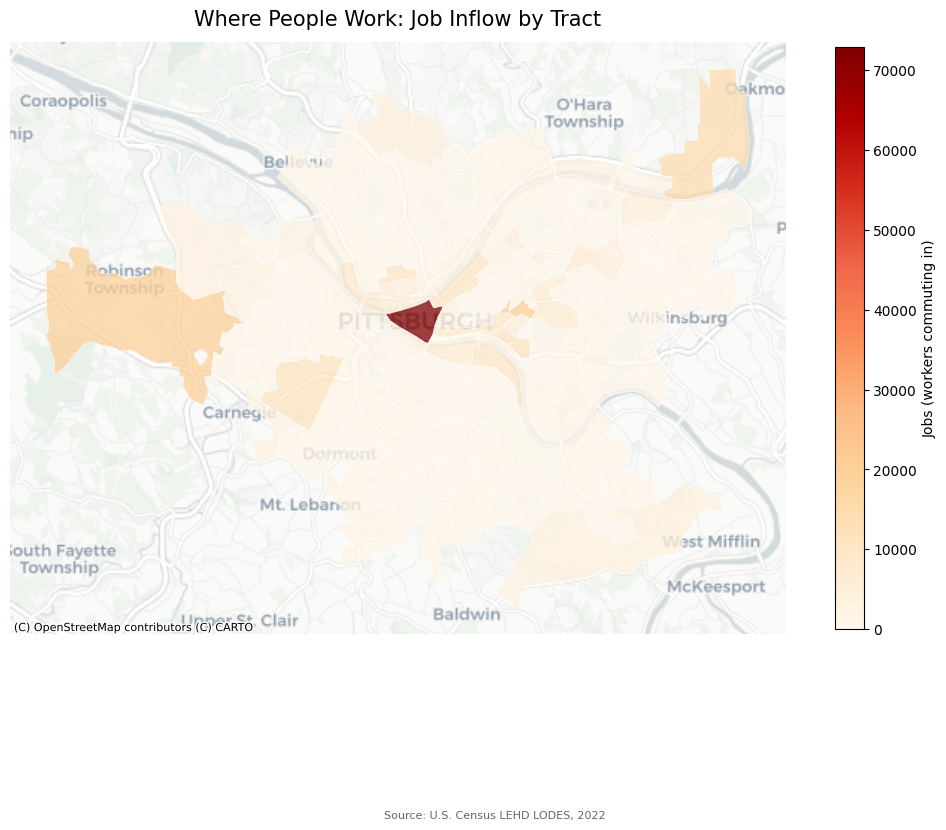

In [11]:
tract_flow_3857 = tract_flow_pgh.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

tract_flow_3857.plot(column="jobs_inflow", cmap=FLOW_CMAP, alpha=0.75, edgecolor="white",
                      linewidth=0.4, legend=True, ax=ax,
                      legend_kwds={"label": "Jobs (workers commuting in)", "shrink": 0.6})

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Where People Work: Job Inflow by Tract", fontsize=15, pad=12)
ax.set_axis_off()
fig.text(0.5, 0.02, f"Source: U.S. Census LEHD LODES, {LODES_YEAR}", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("pittsburgh_job_inflow_map.png", dpi=200, bbox_inches="tight")
plt.show()


That dark cluster is almost certainly Downtown/the Golden Triangle — worth confirming once you see it render, but this is exactly the kind of "oh, that's obviously Downtown" recognition that a real basemap gives you for free, versus a blank tract shape.

## Save exports for the next notebook

In [12]:
edges_export = edges.reset_index()[["u", "v", "key", "name", "highway", "road_class", "length"]].copy()
edges_export["highway"] = edges_export["highway"].apply(lambda v: str(v) if isinstance(v, list) else v)
edges_export.to_csv("pittsburgh_road_hierarchy_edges.csv", index=False)

tract_flow_export = tract_flow_pgh.drop(columns="geometry")
tract_flow_export.to_csv("pittsburgh_tract_commute_flows.csv", index=False)

print("Saved pittsburgh_road_hierarchy_edges.csv  --", len(edges_export), "rows")
print("Saved pittsburgh_tract_commute_flows.csv   --", len(tract_flow_export), "rows")


Saved pittsburgh_road_hierarchy_edges.csv  -- 23661 rows
Saved pittsburgh_tract_commute_flows.csv   -- 176 rows


In [13]:
from google.colab import files

files.download("pittsburgh_road_hierarchy_edges.csv")
files.download("pittsburgh_tract_commute_flows.csv")
files.download("pittsburgh_road_hierarchy_map.png")
files.download("pittsburgh_job_inflow_map.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just:
- Pulled Pittsburgh's drivable road network and classified it by functional hierarchy — the same nodes/edges structure from Project 1, now with capacity-relevant attributes
- Learned the one-line `contextily` technique for putting data on a real, recognizable map
- Brought in genuine origin-destination commuting flow data — real movement, not a proxy
- Mapped where jobs concentrate across Pittsburgh tracts

**Next up (EDA #2 of this project):** we'll dig deeper into the flow data itself — which tracts send the most commuters where, whether that lines up with the road hierarchy we just mapped, and start thinking about how these flows translate into edge weights for the simulation in Project 4.